# Trabajo Práctico N° 1 — Un primer encuentro con la EPH

**Taller de Programación — Universidad de Buenos Aires**  
**Grupo 7 — Definición: _Lower-tier informal wage employees_**

**Integrantes:**

1.   Antony Araujo Guevara
2.   Erick Huamanchumo Luis




## 0. Preparación del entorno de trabajo

En esta primera parte se cargan las librerías necesarias, se crean las carpetas donde se guardarán los archivos y se prepara Google Colab para trabajar con las bases de datos que se subirán desde la computadora.


In [4]:
from pathlib import Path
import sys
import json, textwrap, math, warnings
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore")

EN_COLAB = "google.colab" in sys.modules
MODO_CARGA = "subir"
BASE = Path("/content/TP1_Grupo7") if EN_COLAB else Path.cwd().resolve()

RAW = BASE / "data" / "raw"
PROC = BASE / "data" / "processed"
FIG = BASE / "resultados" / "figuras"
TAB = BASE / "resultados" / "tablas"
SRC = BASE / "src"

for carpeta in [RAW, PROC, FIG, TAB, SRC]:
    carpeta.mkdir(parents=True, exist_ok=True)

if EN_COLAB and MODO_CARGA == "subir":
    esperados = {"usu_individual_T424.xlsx", "usu_individual_T425.xlsx"}
    existentes = {archivo.name for archivo in RAW.glob("*")}

    if not esperados.issubset(existentes):
        from google.colab import files

        print("Seleccione simultáneamente las siguientes bases oficiales:")
        print("• usu_individual_T424.xlsx")
        print("• usu_individual_T425.xlsx\n")

        uploaded = files.upload()

        for nombre, contenido in uploaded.items():
            destino = RAW / Path(nombre).name
            destino.write_bytes(contenido)
            print(f"Archivo guardado: {destino}")

print(f"Carpeta de trabajo: {BASE}")
print(f"Carpeta de bases: {RAW}")

def localizar_base(anio):
    sufijo='424' if anio==2024 else '425'
    candidatos=[
        RAW/f'usu_individual_T{sufijo}.xlsx', RAW/f'usu_individual_t{sufijo}.xlsx',
        RAW/f'usu_individual_T{sufijo}.xls', RAW/f'usu_individual_t{sufijo}.xls',
        RAW/f'usu_individual_T{sufijo}.txt', RAW/f'usu_individual_t{sufijo}.txt'
    ]
    for p in candidatos:
        if p.exists(): return p
    raise FileNotFoundError(
        f"No se encontró la base del año {anio} en {RAW}. "
        "Verifique que haya cargado usu_individual_T424.xlsx y "
        "usu_individual_T425.xlsx con esos nombres."
    )
FILES={2024:localizar_base(2024),2025:localizar_base(2025)}
ID_VARS=['CODUSU','ANO4','TRIMESTRE','NRO_HOGAR','PONDERA']
VARS_INTERES=['CH04','CH06','CH07','CH08','NIVEL_ED','ESTADO','CAT_OCUP','EMPLEO','SECTOR','PP04C','PP04D_COD','P21','P47T','PP07H','PP3E_TOT','REGION','AGLOMERADO','PP04B_COD','PP04G','COMPONENTE']
AUX=['PP04C99','PP04B1']
KEEP=ID_VARS+VARS_INTERES+AUX
FACTOR_2024_A_2025=1.315  # IPC nacional dic-2025 / dic-2024: +31,5%

LABELS={
'CH04':'Sexo','CH06':'Edad','CH07':'Estado civil','CH08':'Cobertura de salud','NIVEL_ED':'Nivel educativo','ESTADO':'Condición de actividad','CAT_OCUP':'Categoría ocupacional','EMPLEO':'Formalidad del empleo','SECTOR':'Sector productivo','PP04C':'Tamaño del establecimiento','PP04D_COD':'Código de ocupación','P21':'Ingreso ocupación principal','P47T':'Ingreso total individual','PP07H':'Descuento jubilatorio','PP3E_TOT':'Horas semanales','REGION':'Región','AGLOMERADO':'Aglomerado','PP04B_COD':'Actividad económica','PP04G':'Lugar de trabajo','COMPONENTE':'N.º de componente'
}

def read_one(path, year):
    if path.suffix.lower() in ['.xlsx','.xls']:
        df=pd.read_excel(path)
    else:
        df=pd.read_csv(path,sep=';',low_memory=False,encoding='utf-8-sig')
    df.columns=[str(c).strip().upper() for c in df.columns]
    missing=[c for c in KEEP if c not in df.columns]
    if missing: raise ValueError(f'Faltan variables en {year}: {missing}')
    df=df[KEEP].copy()
    for c in KEEP:
        if c!='CODUSU': df[c]=pd.to_numeric(df[c],errors='coerce')
    df['CODUSU']=df['CODUSU'].astype('string')
    df['ANIO']=year
    return df

def clean(df):
    d=df.copy()
    for c,bad in {
        'CH07':[9], 'CH08':[9], 'NIVEL_ED':[9], 'CAT_OCUP':[9],
        'EMPLEO':[9], 'SECTOR':[9], 'PP04C':[99], 'PP04C99':[9],
        'PP07H':[0,9], 'PP04G':[0,99], 'PP04D_COD':[0,99999],
        'PP04B_COD':[0,99999], 'PP3E_TOT':[999]
    }.items():
        d[c]=d[c].mask(d[c].isin(bad))
    # Ingresos negativos (principalmente -9) representan no respuesta.
    for c in ['P21','P47T']:
        d[c]=pd.to_numeric(d[c],errors='coerce')
        d[c]=d[c].mask(d[c]<0)
    # Rango lógico de edad; valores extremos de horas quedan como dato observado salvo 999.
    d['CH06']=d['CH06'].mask((d['CH06']<0)|(d['CH06']>110))
    # Armonización a pesos de dic-2025.
    mask=d['ANO4'].eq(2024)
    d.loc[mask,'P21']=d.loc[mask,'P21']*FACTOR_2024_A_2025
    d.loc[mask,'P47T']=d.loc[mask,'P47T']*FACTOR_2024_A_2025
    # Se generan Dummies interpretables.
    d['mujer']=np.where(d['CH04'].eq(2),1,np.where(d['CH04'].eq(1),0,np.nan))
    d['casado_unido']=np.where(d['CH07'].isin([1,2]),1,np.where(d['CH07'].notna(),0,np.nan))
    d['educacion_superior']=np.where(d['NIVEL_ED'].isin([5,6]),1,np.where(d['NIVEL_ED'].notna(),0,np.nan))
    d['ocupado']=np.where(d['ESTADO'].eq(1),1,np.where(d['ESTADO'].notna(),0,np.nan))
    d['asalariado']=np.where(d['CAT_OCUP'].eq(3),1,np.where(d['CAT_OCUP'].notna(),0,np.nan))
    d['sin_descuento_jubilatorio']=np.where(d['PP07H'].eq(2),1,np.where(d['PP07H'].eq(1),0,np.nan))
    return d


Seleccione simultáneamente las siguientes bases oficiales:
• usu_individual_T424.xlsx
• usu_individual_T425.xlsx



Saving usu_individual_T424.xlsx to usu_individual_T424.xlsx
Saving usu_individual_T425.xlsx to usu_individual_T425.xlsx
Archivo guardado: /content/TP1_Grupo7/data/raw/usu_individual_T424.xlsx
Archivo guardado: /content/TP1_Grupo7/data/raw/usu_individual_T425.xlsx
Carpeta de trabajo: /content/TP1_Grupo7
Carpeta de bases: /content/TP1_Grupo7/data/raw


## 1. Preparación y unión de las bases de datos:

En esta sección se cargan las bases correspondientes a 2024 y 2025, se seleccionan y ordenan las variables necesarias, se corrigen valores inconsistentes y se crean nuevas variables para facilitar el análisis. Además, los ingresos de 2024 se actualizan para poder compararlos correctamente con los de 2025. Finalmente, ambas bases se unen en una sola base de datos armonizada.

In [5]:
# En esta sección se desarrollan los puntos: 2.a, 2.b, 5 y 6 del trabajo práctico
frames=[]
for yr,p in FILES.items(): frames.append(clean(read_one(p,yr)))
base=pd.concat(frames,ignore_index=True)

In [6]:
base.head()
base.shape

(90563, 34)

## 2. Clasificación de las personas según su condición de actividad: Desarrollo de los incisos 3 y 4.

En esta parte se divide la base general en tres grupos. Primero, se identifican las personas que sí respondieron la pregunta sobre su condición de actividad laboral. Luego, se separan aquellas que no brindaron una respuesta. Finalmente, dentro del grupo que respondió, se seleccionan únicamente las personas ocupadas, ya que serán la población utilizada para el análisis de informalidad laboral. Además, el código muestra cuántas observaciones contiene cada una de estas bases.

In [7]:
# En esta sección se desarrollan los puntos 3 y 4: sub-bases de respuesta y personas ocupadas
respondieron = base[base['ESTADO'].ne(0)].copy()
norespondieron = base[base['ESTADO'].eq(0)].copy()
ocupados = respondieron[respondieron['ESTADO'].eq(1)].copy()

print(f'Base total: {len(base):,}')
print(f'Respondieron ESTADO: {len(respondieron):,}')
print(f'No respondieron ESTADO: {len(norespondieron):,}')
print(f'Personas ocupadas: {len(ocupados):,}')

Base total: 90,563
Respondieron ESTADO: 90,442
No respondieron ESTADO: 121
Personas ocupadas: 40,830


## 3. Construcción del indicador de informalidad lower-tier: Desarrollo del inciso 10.

En esta etapa se construye el indicador de informalidad laboral asignado al grupo. El análisis se centra únicamente en las personas ocupadas que trabajan como asalariadas. A partir de la información sobre aportes jubilatorios y tamaño del establecimiento, se clasifican los trabajadores en cuatro grupos: asalariados formales, informales lower-tier, informales upper-tier y casos que no pueden clasificarse con la información disponible.

Se considera formal al asalariado que cuenta con descuento jubilatorio. En cambio, se identifica como informal lower-tier al asalariado que no tiene descuento jubilatorio y trabaja en una unidad productiva pequeña, como un establecimiento de hasta cinco personas, un servicio doméstico u otra actividad de baja escala.

In [8]:
# En esta sección se desarrolla el punto 10: definición de informalidad lower-tier
wa=ocupados[ocupados.CAT_OCUP.eq(3)].copy()
pequeño=(wa.PP04C.between(1,5)) | ((wa.PP04C.isna()) & wa.PP04C99.eq(1)) | wa.PP04B1.eq(1) | wa.SECTOR.eq(3)
largo=(wa.PP04C.between(6,12)) | ((wa.PP04C.isna()) & wa.PP04C99.isin([2,3]))
wa['estatus_laboral']=np.select([
    wa.PP07H.eq(1),
    wa.PP07H.eq(2)&pequeño,
    wa.PP07H.eq(2)&largo
],['Formal asalariado','Informal lower-tier','Informal upper-tier'],default='No clasificable')

In [9]:
wa.head()

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,...,PP04C99,PP04B1,ANIO,mujer,casado_unido,educacion_superior,ocupado,asalariado,sin_descuento_jubilatorio,estatus_laboral
3,TQRMNOSQTHMKLQCDEHPJB00872830,2024,4,1,380,1,30.0,1.0,1.0,6,...,0.0,2.0,2024,0.0,1.0,1.0,1.0,1.0,0.0,Formal asalariado
4,TQRMNOSQTHMKLQCDEHPJB00872830,2024,4,1,380,2,30.0,1.0,1.0,6,...,0.0,2.0,2024,1.0,1.0,1.0,1.0,1.0,0.0,Formal asalariado
5,TQRMNOPYTHLMKOCDEIHJF00854747,2024,4,1,226,1,44.0,2.0,1.0,5,...,0.0,2.0,2024,0.0,1.0,1.0,1.0,1.0,0.0,Formal asalariado
6,TQRMNOPYTHLMKOCDEIHJF00854747,2024,4,1,226,2,46.0,2.0,1.0,6,...,0.0,2.0,2024,1.0,1.0,1.0,1.0,1.0,0.0,Formal asalariado
10,TQRMNOQQSHKKPPCDEIJAH00872831,2024,4,1,2049,1,36.0,1.0,1.0,6,...,0.0,2.0,2024,0.0,1.0,1.0,1.0,1.0,0.0,Formal asalariado


## 4. Exportación de bases procesadas

In [10]:
# guardar bases comprimidas
base.to_csv(PROC/'base_armonizada.csv.gz',index=False,compression='gzip')
respondieron.to_csv(PROC/'respondieron.csv.gz',index=False,compression='gzip')
norespondieron.to_csv(PROC/'norespondieron.csv.gz',index=False,compression='gzip')
ocupados.to_csv(PROC/'ocupados.csv.gz',index=False,compression='gzip')
wa.to_csv(PROC/'asalariados_clasificados.csv.gz',index=False,compression='gzip')

## 5. Resumen de las muestras

In [11]:
# Resumen de muestras
rows=[]
for yr in [2024,2025]:
    b=base[base.ANO4.eq(yr)]; nr=norespondieron[norespondieron.ANO4.eq(yr)]; r=respondieron[respondieron.ANO4.eq(yr)]; o=ocupados[ocupados.ANO4.eq(yr)]
    rows.append({'Año':yr,'Base total':len(b),'No respondieron ESTADO':len(nr),'No respondieron ponderado':round(nr.PONDERA.sum()),'Respondieron':len(r),'Ocupados':len(o),'Ocupados ponderado':round(o.PONDERA.sum())})
resumen=pd.DataFrame(rows); resumen.to_csv(TAB/'resumen_muestras.csv',index=False)

## 6. Inciso 7 — Valores faltantes y heatmap

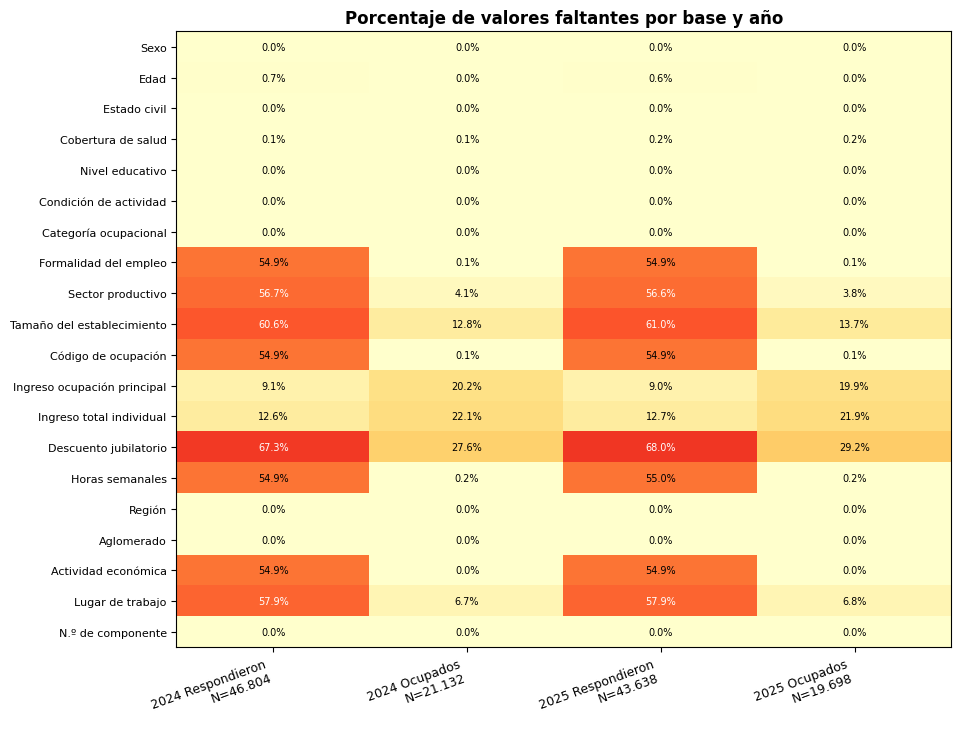

In [12]:
# En esta sección se desarrolla el punto 7: Valores faltantes y heatmap
# Faltantes por año/base
miss=[]
for yr in [2024,2025]:
    for nom,df in [('Respondieron',respondieron),('Ocupados',ocupados)]:
        z=df[df.ANO4.eq(yr)]
        for v in VARS_INTERES:
            miss.append({'Año':yr,'Base':nom,'Variable':v,'Porcentaje_faltantes':100*z[v].isna().mean(),'N':len(z)})
missing=pd.DataFrame(miss); missing.to_csv(TAB/'faltantes.csv',index=False)
piv=missing.pivot(index='Variable',columns=['Año','Base'],values='Porcentaje_faltantes')
piv=piv.reindex(VARS_INTERES)
fig,ax=plt.subplots(figsize=(10,8))
im=ax.imshow(piv.values,aspect='auto',vmin=0,vmax=100,cmap='YlOrRd')
ax.set_yticks(range(len(piv))); ax.set_yticklabels([LABELS.get(x,x) for x in piv.index],fontsize=8)
col_labels=[]
for yr,bas in piv.columns:
    n=int(missing[(missing.Año==yr)&(missing.Base==bas)].N.iloc[0]); col_labels.append(f'{yr} {bas}\nN={n:,}'.replace(',','.'))
ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels,rotation=20,ha='right',fontsize=9)
for i in range(piv.shape[0]):
  for j in range(piv.shape[1]):
    v=piv.iloc[i,j]; ax.text(j,i,f'{v:.1f}%',ha='center',va='center',fontsize=7,color='white' if v>55 else 'black')
ax.set_title('Porcentaje de valores faltantes por base y año',fontweight='bold')
plt.show()
fig.colorbar(im,ax=ax,label='% faltantes'); fig.tight_layout(); fig.savefig(FIG/'heatmap_faltantes.png',dpi=220,bbox_inches='tight'); plt.close(fig)

## 7. Inciso 8 — Matrices de correlación

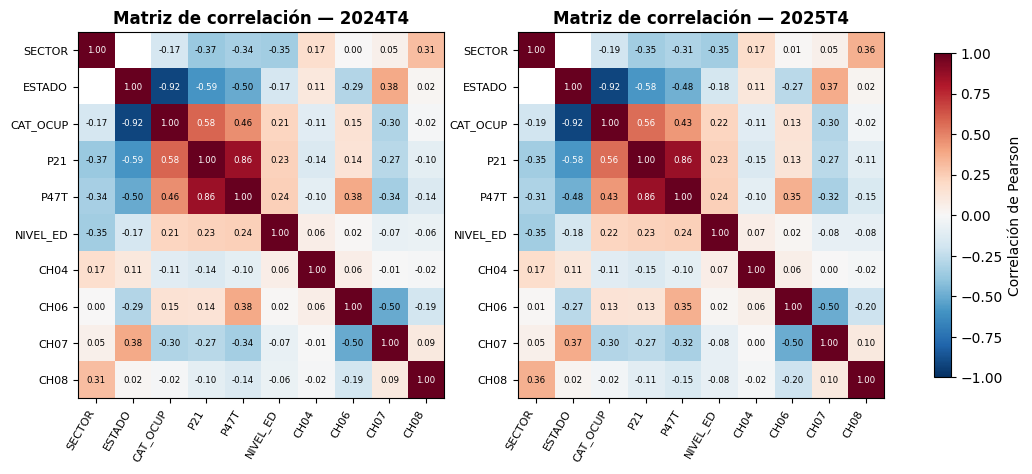

In [13]:
# En esta sección se desarrolla el punto 8: Matrices de correlación
# Correlaciones
corr_vars=['SECTOR','ESTADO','CAT_OCUP','P21','P47T','NIVEL_ED','CH04','CH06','CH07','CH08']
corrs={}
for yr in [2024,2025]:
    z=respondieron[respondieron.ANO4.eq(yr)][corr_vars]
    corrs[yr]=z.corr(method='pearson',min_periods=100)
    corrs[yr].to_csv(TAB/f'correlacion_{yr}.csv')
fig,axes=plt.subplots(1,2,figsize=(13,5.4))
for ax,yr in zip(axes,[2024,2025]):
    c=corrs[yr]; im=ax.imshow(c.values,vmin=-1,vmax=1,cmap='RdBu_r')
    ax.set_xticks(range(len(c))); ax.set_xticklabels(c.columns,rotation=60,ha='right',fontsize=8)
    ax.set_yticks(range(len(c))); ax.set_yticklabels(c.index,fontsize=8)
    ax.set_title(f'Matriz de correlación — {yr}T4',fontweight='bold')
    for i in range(len(c)):
      for j in range(len(c)):
        if np.isfinite(c.iloc[i,j]): ax.text(j,i,f'{c.iloc[i,j]:.2f}',ha='center',va='center',fontsize=6.2,color='white' if abs(c.iloc[i,j])>.55 else 'black')
fig.colorbar(im,ax=axes.ravel().tolist(),shrink=.78,label='Correlación de Pearson')
plt.show()
fig.subplots_adjust(left=.07,right=.92,bottom=.2,top=.9,wspace=.28); fig.savefig(FIG/'correlaciones_2024_2025.png',dpi=220,bbox_inches='tight'); plt.close(fig)
diff=(corrs[2025]-corrs[2024]).abs(); mask=np.triu(np.ones(diff.shape),1).astype(bool)
stack=diff.where(mask).stack().sort_values(ascending=False)
max_pair=stack.index[0]; max_diff=float(stack.iloc[0]); mean_diff=float(stack.mean())

## 8. Inciso 9 — Estadística descriptiva

In [14]:
# En esta sección se desarrolla el punto 9: Estadística descriptiva
# Estadística descriptiva por año (respondieron)
def desc_table(df,year):
    out=[]
    for v in VARS_INTERES:
        s=pd.to_numeric(df.loc[df.ANO4.eq(year),v],errors='coerce').dropna()
        q=s.quantile([.01,.25,.5,.75,.99]) if len(s) else pd.Series(index=[.01,.25,.5,.75,.99],dtype=float)
        out.append({'Variable':v,'n':len(s),'promedio':s.mean(),'desvío_estándar':s.std(),'mínimo':s.min(),'p1':q.get(.01),'p25':q.get(.25),'p50':q.get(.5),'p75':q.get(.75),'p99':q.get(.99),'máximo':s.max()})
    return pd.DataFrame(out)
for yr in [2024,2025]: desc_table(respondieron,yr).to_csv(TAB/f'descriptivos_{yr}.csv',index=False)

## 9. Inciso 10 — Tabla ponderada de formalidad e informalidad

In [15]:
# En esta sección se desarrolla el punto 10: tabla de formalidad/informalidad ponderada
# Tabla informalidad ponderada
def wshare(g,cat):
    den=g.PONDERA.sum(); return 100*g.loc[g.estatus_laboral.eq(cat),'PONDERA'].sum()/den if den else np.nan
infrows=[]; fullrows=[]
for yr in [2024,2025]:
    y=wa[wa.ANO4.eq(yr)]
    for sexo,sub in [('Total',y),('Mujeres',y[y.CH04.eq(2)]),('Hombres',y[y.CH04.eq(1)])]:
        cls=sub[sub.estatus_laboral.isin(['Formal asalariado','Informal lower-tier'])]
        infrows.append({'Año':yr,'Grupo':sexo,'Formal (%)':wshare(cls,'Formal asalariado'),'Informal lower-tier (%)':wshare(cls,'Informal lower-tier'),'N muestral clasificado':len(cls),'Población expandida':round(cls.PONDERA.sum())})
        fullrows.append({'Año':yr,'Grupo':sexo,**{c:wshare(sub,c) for c in ['Formal asalariado','Informal lower-tier','Informal upper-tier','No clasificable']},'N':len(sub)})
inf=pd.DataFrame(infrows); inf.to_csv(TAB/'informalidad_formal_lower_tier.csv',index=False)
pd.DataFrame(fullrows).to_csv(TAB/'informalidad_tres_categorias.csv',index=False)

## 10. Inciso 10 — Gráfico por sexo y año

In [16]:
# Gráfico tabla de informalidad
fig,ax=plt.subplots(figsize=(9,4.5))
plot=inf.copy(); plot['etiqueta']=plot['Año'].astype(str)+' '+plot['Grupo']
x=np.arange(len(plot)); width=.38
ax.bar(x-width/2,plot['Formal (%)'],width,label='Formal')
ax.bar(x+width/2,plot['Informal lower-tier (%)'],width,label='Informal lower-tier')
for i,row in plot.iterrows():
    ax.text(i-width/2,row['Formal (%)']+1,f"{row['Formal (%)']:.1f}%",ha='center',fontsize=8)
    ax.text(i+width/2,row['Informal lower-tier (%)']+1,f"{row['Informal lower-tier (%)']:.1f}%",ha='center',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(plot.etiqueta,rotation=22,ha='right'); ax.set_ylabel('% ponderado')
ax.set_ylim(0,100); ax.set_title('Formalidad e informalidad lower-tier por sexo',fontweight='bold'); ax.legend(frameon=False,ncol=2); ax.grid(axis='y',alpha=.25); fig.tight_layout(); fig.savefig(FIG/'informalidad_por_sexo.png',dpi=220); plt.close(fig)

## 11. Inciso 11 — Histogramas y densidades kernel de ingresos

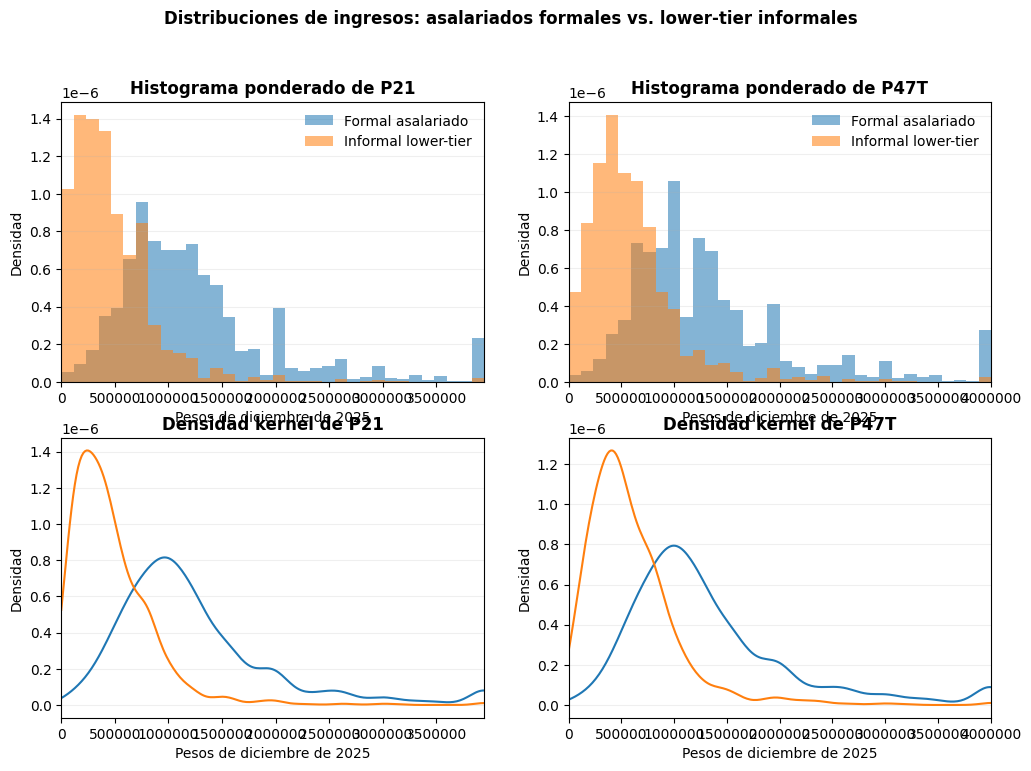

In [19]:
# En esta sección se desarrolla el punto 11: histogramas y densidades kernel
# Distribución de ingresos: pool 2024-2025 en pesos 2025; solo formal/lower tier y >0, eje a p99
dist=wa[wa.estatus_laboral.isin(['Formal asalariado','Informal lower-tier'])].copy()
fig,axes=plt.subplots(2,2,figsize=(12,8))
for col,axes_col in zip(['P21','P47T'],[axes[:,0],axes[:,1]]):
    z=dist[dist[col].gt(0)&dist[col].notna()].copy(); xmax=z[col].quantile(.99); bins=np.linspace(0,xmax,35)
    for status in ['Formal asalariado','Informal lower-tier']:
        g=z[z.estatus_laboral.eq(status)]; axes_col[0].hist(g[col].clip(upper=xmax),bins=bins,weights=g.PONDERA,density=True,alpha=.55,label=status)
    axes_col[0].set_title(f'Histograma ponderado de {col}',fontweight='bold'); axes_col[0].set_xlim(0,xmax); axes_col[0].ticklabel_format(axis='x',style='plain'); axes_col[0].grid(axis='y',alpha=.2)
    xs=np.linspace(0,xmax,250)
    for status in ['Formal asalariado','Informal lower-tier']:
        g=z[z.estatus_laboral.eq(status)]; vals=g[col].clip(upper=xmax).to_numpy(); weights=g.PONDERA.to_numpy()
        if len(vals)>10:
            kde=gaussian_kde(vals,weights=weights,bw_method='scott'); axes_col[1].plot(xs,kde(xs),label=status)
    axes_col[1].set_title(f'Densidad kernel de {col}',fontweight='bold'); axes_col[1].set_xlim(0,xmax); axes_col[1].ticklabel_format(axis='x',style='plain'); axes_col[1].grid(axis='y',alpha=.2)
for ax in axes.ravel(): ax.set_xlabel('Pesos de diciembre de 2025'); ax.set_ylabel('Densidad')
axes[0,0].legend(frameon=False); axes[0,1].legend(frameon=False)
fig.suptitle('Distribuciones de ingresos: asalariados formales vs. lower-tier informales',fontweight='bold',y=.995)
plt.show()
fig.tight_layout(); fig.savefig(FIG/'distribuciones_ingresos_4_paneles.png',dpi=220,bbox_inches='tight'); plt.close(fig)

## 12. Resumen ponderado de ingresos

In [20]:
# Medias/medianas ponderadas para comentarios
def weighted_quantile(values, quantile, weights):
    m=np.isfinite(values)&np.isfinite(weights); values=np.asarray(values)[m]; weights=np.asarray(weights)[m]
    if len(values)==0:return np.nan
    idx=np.argsort(values); values=values[idx]; weights=weights[idx]; c=np.cumsum(weights)-.5*weights; return np.interp(quantile,c/c[-1],values)
income_summary=[]
for yr in [2024,2025]:
 for st in ['Formal asalariado','Informal lower-tier']:
  g=wa[(wa.ANO4==yr)&(wa.estatus_laboral==st)]
  for c in ['P21','P47T']:
   q=g[g[c]>0]
   income_summary.append({'Año':yr,'Estatus':st,'Ingreso':c,'N':len(q),'Media ponderada':np.average(q[c],weights=q.PONDERA) if len(q) else np.nan,'Mediana ponderada':weighted_quantile(q[c].values,.5,q.PONDERA.values)})
pd.DataFrame(income_summary).to_csv(TAB/'resumen_ingresos.csv',index=False)

## 13. Exportación del resumen de resultados

In [21]:
# Se genera un archivo JSON para informe
result={
 'factor':FACTOR_2024_A_2025,
 'resumen':resumen.to_dict(orient='records'),
 'max_corr_pair':list(max_pair),'max_corr_diff':max_diff,'mean_corr_diff':mean_diff,
 'informalidad':inf.to_dict(orient='records'),
 'income_summary':income_summary,
 'missing_selected':missing[missing.Variable.isin(['P21','P47T','PP07H','PP04C','EMPLEO','SECTOR'])].to_dict(orient='records')
}
(BASE/'resultados'/'resumen_resultados.json').write_text(json.dumps(result,ensure_ascii=False,indent=2),encoding='utf-8')
print(json.dumps(result,ensure_ascii=False,indent=2))

{
  "factor": 1.315,
  "resumen": [
    {
      "Año": 2024,
      "Base total": 46860,
      "No respondieron ESTADO": 56,
      "No respondieron ponderado": 70835,
      "Respondieron": 46804,
      "Ocupados": 21132,
      "Ocupados ponderado": 13596484
    },
    {
      "Año": 2025,
      "Base total": 43703,
      "No respondieron ESTADO": 65,
      "No respondieron ponderado": 62868,
      "Respondieron": 43638,
      "Ocupados": 19698,
      "Ocupados ponderado": 13503383
    }
  ],
  "max_corr_pair": [
    "SECTOR",
    "CH08"
  ],
  "max_corr_diff": 0.04792914742397009,
  "mean_corr_diff": 0.010595299018598988,
  "informalidad": [
    {
      "Año": 2024,
      "Grupo": "Total",
      "Formal (%)": 76.44000356304596,
      "Informal lower-tier (%)": 23.559996436954044,
      "N muestral clasificado": 12968,
      "Población expandida": 8217688
    },
    {
      "Año": 2024,
      "Grupo": "Mujeres",
      "Formal (%)": 72.71510357949502,
      "Informal lower-tier (%)": 27.2

## Observaciones de ejecución

- Los ingresos de 2024T4 se convierten a pesos de diciembre de 2025 mediante `FACTOR_2024_A_2025 = 1.315`.
- Las salidas se guardan en `data/processed/`, `resultados/tablas/` y `resultados/figuras/`.
- Las tablas y gráficos deben interpretarse después de ejecutar el cuaderno con las bases originales en `data/raw/`.
- El código conserva los ponderadores muestrales (`PONDERA`) para los indicadores poblacionales.

## 10. Descargar los resultados de Google Colab

Esta celda comprime las bases procesadas, tablas y figuras. Las bases originales no se incluyen para evitar que el archivo sea demasiado pesado.


In [22]:
# Se crea un ZIP con los resultados del trabajo
zip_salida = Path("/content/TP1_Grupo7_resultados.zip") if EN_COLAB else BASE / "TP1_Grupo7_resultados.zip"

with zipfile.ZipFile(zip_salida, "w", zipfile.ZIP_DEFLATED) as archivo_zip:
    for carpeta in [PROC, BASE / "resultados"]:
        if carpeta.exists():
            for archivo in carpeta.rglob("*"):
                if archivo.is_file():
                    archivo_zip.write(
                        archivo,
                        arcname=str(archivo.relative_to(BASE))
                    )

print(f"Archivo creado: {zip_salida}")

if EN_COLAB:
    from google.colab import files
    files.download(str(zip_salida))


Archivo creado: /content/TP1_Grupo7_resultados.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>